# ENSO Forecasting: Complete Model Comparison

This notebook runs the full ENSO forecasting workflow in one place:

1. Load and preprocess the NOAA ERSSTv5 Nino 3.4 SST series
2. Create 12-month sliding-window regression features
3. Train OLS, CART, Random Forest, XGBoost, and 1D CNN models
4. Evaluate all models using RMSE, MAE, and R^2
5. Save prediction files, metrics, plots, and the final comparison table

This is the main reproducibility notebook for the project.

## 1. Import Libraries

In [22]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Input, MaxPooling1D
from tensorflow.keras.models import Sequential
from xgboost import XGBRegressor

np.random.seed(42)
tf.random.set_seed(42)

## 2. Load and Prepare the Data

In [23]:
data_dir = Path("../data")
if not data_dir.exists():
    data_dir = Path("data")
data_dir.mkdir(parents=True, exist_ok=True)

url = "https://www.cpc.ncep.noaa.gov/data/indices/ersst5.nino.mth.91-20.ascii"
raw_df = pd.read_table(url, sep=r"\s+", engine="python")

raw_df["YR"] = pd.to_numeric(raw_df["YR"], errors="coerce")
raw_df["MON"] = pd.to_numeric(raw_df["MON"], errors="coerce")
raw_df["NINO3.4"] = pd.to_numeric(raw_df["NINO3.4"], errors="coerce")

clean_df = raw_df[["YR", "MON", "NINO3.4"]].copy()
clean_df = clean_df.replace([-99.99, -99.9, -999, -999.0], np.nan).dropna()
clean_df["YR"] = clean_df["YR"].astype(int)
clean_df["MON"] = clean_df["MON"].astype(int)
clean_df["Date"] = pd.to_datetime(dict(year=clean_df["YR"], month=clean_df["MON"], day=1))
clean_df = clean_df.sort_values("Date").reset_index(drop=True)

nino34_series = pd.Series(
    data=clean_df["NINO3.4"].values,
    index=clean_df["Date"],
    name="Nino3.4_Temperature"
)

print(nino34_series.head())
print(nino34_series.tail())
print("Series shape:", nino34_series.shape)

Date
1950-01-01    24.55
1950-02-01    25.06
1950-03-01    25.87
1950-04-01    26.28
1950-05-01    26.18
Name: Nino3.4_Temperature, dtype: float64
Date
2025-12-01    25.93
2026-01-01    25.96
2026-02-01    26.48
2026-03-01    27.27
2026-04-01    28.05
Name: Nino3.4_Temperature, dtype: float64
Series shape: (916,)


## 3. Create Sliding Windows and Chronological Split

In [24]:
WINDOW_SIZE = 12
values = nino34_series.to_numpy(dtype="float32")

def create_sliding_windows(series_values, window_size):
    X, y = [], []
    for i in range(len(series_values) - window_size):
        X.append(series_values[i:i + window_size])
        y.append(series_values[i + window_size])
    return np.array(X), np.array(y)

X_raw, y_raw = create_sliding_windows(values, WINDOW_SIZE)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw,
    y_raw,
    train_size=0.80,
    shuffle=False
)

scaler = StandardScaler()
scaler.fit(X_train_raw.reshape(-1, 1))

X_train = scaler.transform(X_train_raw.reshape(-1, 1)).reshape(X_train_raw.shape)
X_test = scaler.transform(X_test_raw.reshape(-1, 1)).reshape(X_test_raw.shape)
y_train = scaler.transform(y_train_raw.reshape(-1, 1)).reshape(-1)
y_test = scaler.transform(y_test_raw.reshape(-1, 1)).reshape(-1)

feature_columns = [f"month_t_minus_{lag}" for lag in range(WINDOW_SIZE, 0, -1)]
X_train_df = pd.DataFrame(X_train, columns=feature_columns)
X_test_df = pd.DataFrame(X_test, columns=feature_columns)
y_train_df = pd.DataFrame({"target_t": y_train})
y_test_df = pd.DataFrame({"target_t": y_test})

X_train_df.to_csv(data_dir / "X_train.csv", index=False)
X_test_df.to_csv(data_dir / "X_test.csv", index=False)
y_train_df.to_csv(data_dir / "y_train.csv", index=False)
y_test_df.to_csv(data_dir / "y_test.csv", index=False)

print("X_train shape:", X_train_df.shape)
print("X_test shape:", X_test_df.shape)
print("y_train shape:", y_train_df.shape)
print("y_test shape:", y_test_df.shape)

X_train shape: (723, 12)
X_test shape: (181, 12)
y_train shape: (723, 1)
y_test shape: (181, 1)


## 4. Helper Functions

In [25]:
def evaluate_regression(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return rmse, mae, r2

def print_split_metrics(model_name, train_metrics, test_metrics, val_metrics=None):
    print(model_name)
    print(f"Train      RMSE={train_metrics[0]:.4f}  MAE={train_metrics[1]:.4f}  R^2={train_metrics[2]:.4f}")
    if val_metrics is not None:
        print(f"Validation RMSE={val_metrics[0]:.4f}  MAE={val_metrics[1]:.4f}  R^2={val_metrics[2]:.4f}")
    print(f"Test       RMSE={test_metrics[0]:.4f}  MAE={test_metrics[1]:.4f}  R^2={test_metrics[2]:.4f}")
    print()

def add_metric_row(rows, model_name, train_metrics, test_metrics, val_metrics=None):
    row = {
        "Model": model_name,
        "RMSE_Train": train_metrics[0],
        "MAE_Train": train_metrics[1],
        "R2_Train": train_metrics[2],
        "RMSE_Test": test_metrics[0],
        "MAE_Test": test_metrics[1],
        "R2_Test": test_metrics[2],
    }
    if val_metrics is not None:
        row.update({
            "RMSE_Val": val_metrics[0],
            "MAE_Val": val_metrics[1],
            "R2_Val": val_metrics[2],
        })
    rows.append(row)

metrics_rows = []
all_predictions_df = pd.DataFrame({"y_actual": y_test})

## 5. OLS Linear Regression

In [26]:
ols_model = LinearRegression()
ols_model.fit(X_train_df, y_train)

ols_pred_train = ols_model.predict(X_train_df)
ols_pred_test = ols_model.predict(X_test_df)

ols_train_metrics = evaluate_regression(y_train, ols_pred_train)
ols_test_metrics = evaluate_regression(y_test, ols_pred_test)

print_split_metrics("OLS Linear Regression", ols_train_metrics, ols_test_metrics)
add_metric_row(metrics_rows, "OLS Linear Regression", ols_train_metrics, ols_test_metrics)
all_predictions_df["y_pred_OLS"] = ols_pred_test

pd.DataFrame({"y_actual": y_test, "y_pred_OLS": ols_pred_test}).to_csv(data_dir / "ols_test_predictions.csv", index=False)
pd.DataFrame([metrics_rows[-1]]).to_csv(data_dir / "ols_metrics.csv", index=False)

OLS Linear Regression
Train      RMSE=0.2724  MAE=0.2142  R^2=0.9264
Test       RMSE=0.2367  MAE=0.1810  R^2=0.9461



## 6. CART Decision Tree

CART Decision Tree
Train      RMSE=0.2218  MAE=0.1727  R^2=0.9512
Test       RMSE=0.3613  MAE=0.2816  R^2=0.8744



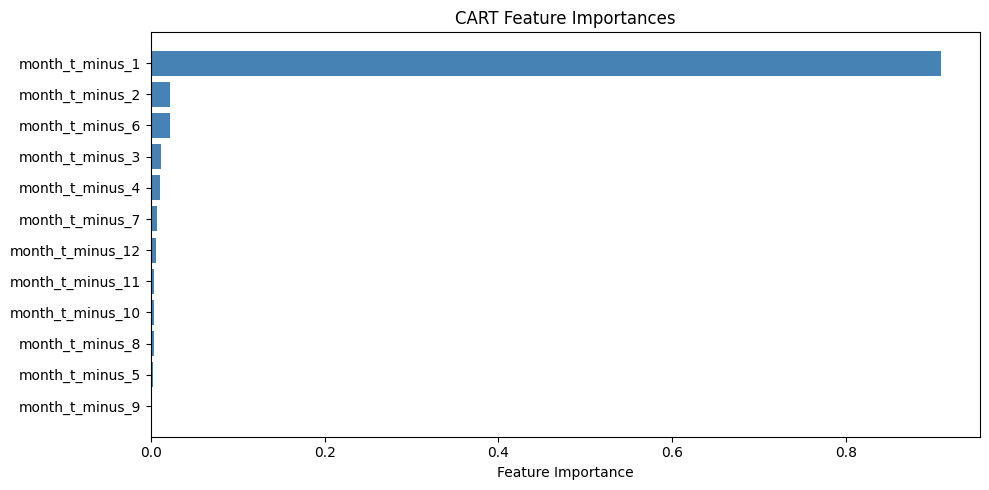

In [27]:
cart_model = DecisionTreeRegressor(min_samples_split=20, random_state=42)
cart_model.fit(X_train_df, y_train)

cart_pred_train = cart_model.predict(X_train_df)
cart_pred_test = cart_model.predict(X_test_df)

cart_train_metrics = evaluate_regression(y_train, cart_pred_train)
cart_test_metrics = evaluate_regression(y_test, cart_pred_test)

print_split_metrics("CART Decision Tree", cart_train_metrics, cart_test_metrics)
add_metric_row(metrics_rows, "CART Decision Tree", cart_train_metrics, cart_test_metrics)
all_predictions_df["y_pred_CART"] = cart_pred_test

pd.DataFrame({"y_actual": y_test, "y_pred_CART": cart_pred_test}).to_csv(data_dir / "cart_test_predictions.csv", index=False)
pd.DataFrame([metrics_rows[-1]]).to_csv(data_dir / "cart_metrics.csv", index=False)

feature_importance_df = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Importance": cart_model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"], color="steelblue")
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("CART Feature Importances")
plt.tight_layout()
plt.savefig(data_dir / "cart_feature_importances.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Ensemble Models

In [28]:
ensemble_models = {
    "Random Forest Regressor": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost Regressor": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        random_state=42,
        objective="reg:squarederror"
    )
}

ensemble_predictions_df = pd.DataFrame({"y_actual": y_test})
ensemble_metric_rows = []

for model_name, model in ensemble_models.items():
    model.fit(X_train_df, y_train)
    pred_train = model.predict(X_train_df)
    pred_test = model.predict(X_test_df)

    train_metrics = evaluate_regression(y_train, pred_train)
    test_metrics = evaluate_regression(y_test, pred_test)

    print_split_metrics(model_name, train_metrics, test_metrics)
    add_metric_row(metrics_rows, model_name, train_metrics, test_metrics)
    ensemble_metric_rows.append(metrics_rows[-1])

    prediction_col = model_name.replace(" ", "_").replace("Regressor", "").strip("_")
    ensemble_predictions_df[f"y_pred_{prediction_col}"] = pred_test
    all_predictions_df[f"y_pred_{prediction_col}"] = pred_test

ensemble_predictions_df.to_csv(data_dir / "ensemble_test_predictions.csv", index=False)
pd.DataFrame(ensemble_metric_rows).to_csv(data_dir / "ensemble_metrics.csv", index=False)

Random Forest Regressor
Train      RMSE=0.1180  MAE=0.0934  R^2=0.9862
Test       RMSE=0.2922  MAE=0.2333  R^2=0.9179

XGBoost Regressor
Train      RMSE=0.0529  MAE=0.0402  R^2=0.9972
Test       RMSE=0.3011  MAE=0.2433  R^2=0.9128



## 8. 1D CNN

Epoch 1/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.7446 - val_loss: 0.4317
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3856 - val_loss: 0.2789
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2906 - val_loss: 0.2305
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.2373 - val_loss: 0.1988
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2010 - val_loss: 0.1728
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1773 - val_loss: 0.1539
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1610 - val_loss: 0.1437
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1512 - val_loss: 0.1372
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1439 - val_loss: 0.1319
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1379 - val_loss: 0.1283
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1327 - val_loss: 0.1235
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1284 - val_l

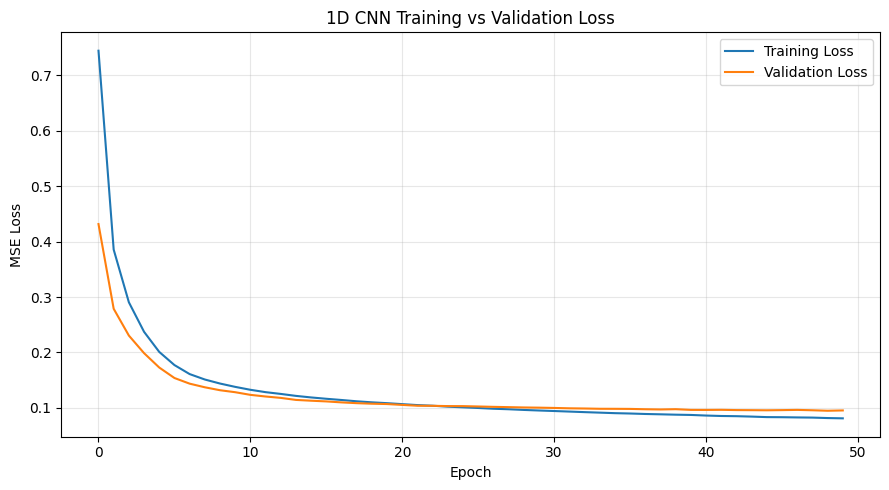

In [29]:
val_fraction = 0.20
val_size = int(len(X_train) * val_fraction)
train_end = len(X_train) - val_size

X_cnn_train_raw = X_train[:train_end]
X_cnn_val_raw = X_train[train_end:]
y_cnn_train = y_train[:train_end]
y_cnn_val = y_train[train_end:]

n_timesteps = X_cnn_train_raw.shape[1]
n_features = 1

X_cnn_train = X_cnn_train_raw.reshape((X_cnn_train_raw.shape[0], n_timesteps, n_features))
X_cnn_val = X_cnn_val_raw.reshape((X_cnn_val_raw.shape[0], n_timesteps, n_features))
X_cnn_test = X_test.reshape((X_test.shape[0], n_timesteps, n_features))

cnn_model = Sequential([
    Input(shape=(n_timesteps, n_features)),
    Conv1D(filters=64, kernel_size=3, activation="relu"),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

cnn_model.compile(optimizer="adam", loss="mse")

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = cnn_model.fit(
    X_cnn_train,
    y_cnn_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_cnn_val, y_cnn_val),
    callbacks=[early_stopping],
    verbose=1
)

cnn_pred_train = cnn_model.predict(X_cnn_train).ravel()
cnn_pred_val = cnn_model.predict(X_cnn_val).ravel()
cnn_pred_test = cnn_model.predict(X_cnn_test).ravel()

cnn_train_metrics = evaluate_regression(y_cnn_train, cnn_pred_train)
cnn_val_metrics = evaluate_regression(y_cnn_val, cnn_pred_val)
cnn_test_metrics = evaluate_regression(y_test, cnn_pred_test)

print_split_metrics("1D CNN", cnn_train_metrics, cnn_test_metrics, cnn_val_metrics)
add_metric_row(metrics_rows, "1D CNN", cnn_train_metrics, cnn_test_metrics, cnn_val_metrics)
all_predictions_df["y_pred_CNN_1D"] = cnn_pred_test

pd.DataFrame({"y_actual": y_test, "y_pred_CNN_1D": cnn_pred_test}).to_csv(data_dir / "cnn_1d_test_predictions.csv", index=False)
pd.DataFrame([metrics_rows[-1]]).to_csv(data_dir / "cnn_1d_metrics.csv", index=False)

plt.figure(figsize=(9, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("1D CNN Training vs Validation Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(data_dir / "cnn_1d_loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Visualize Predictions

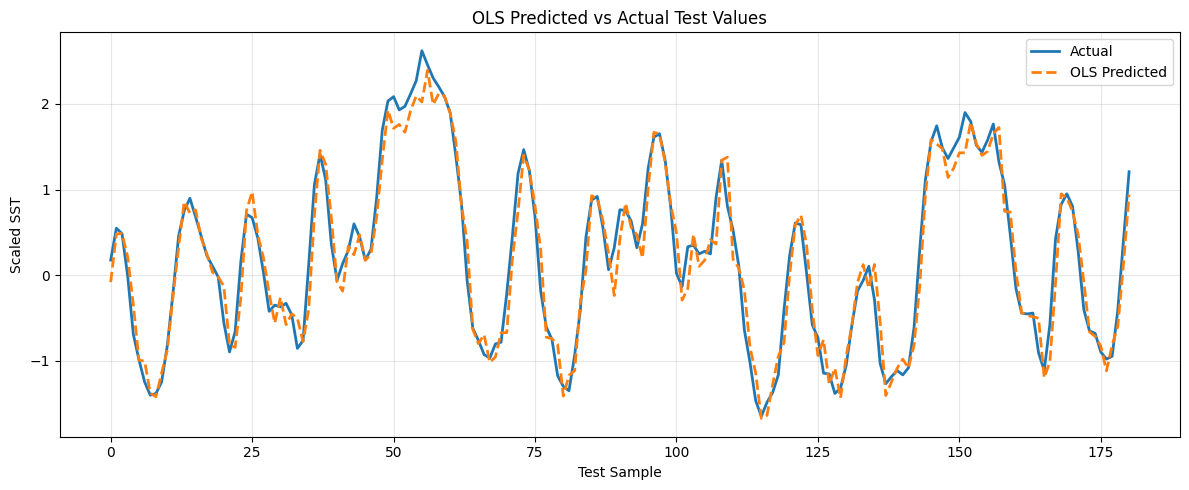

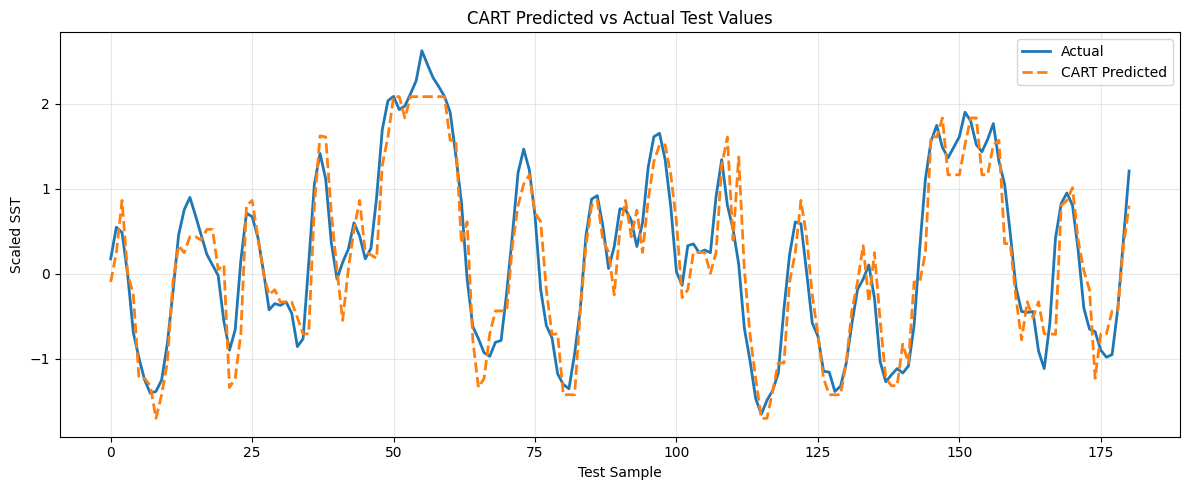

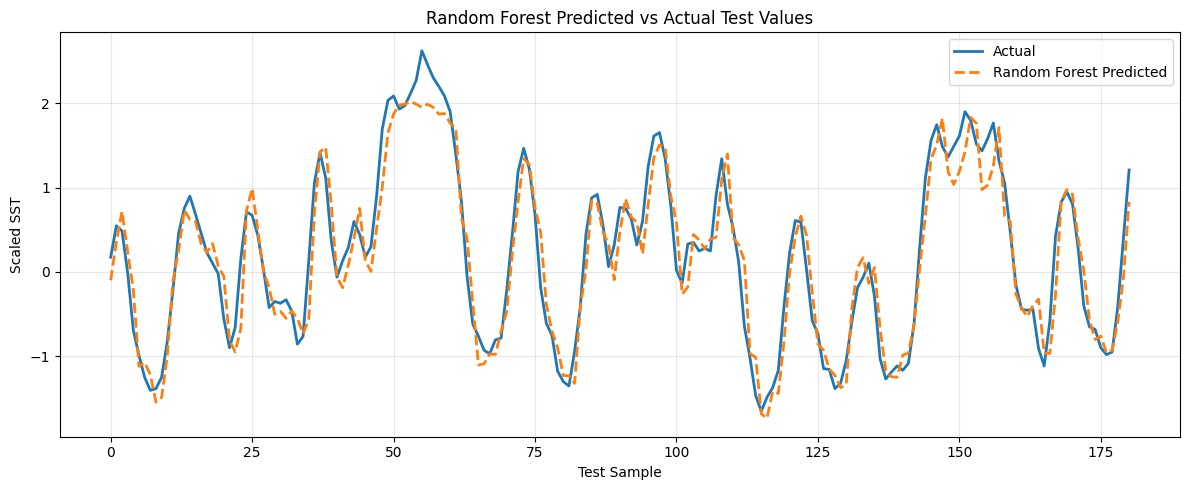

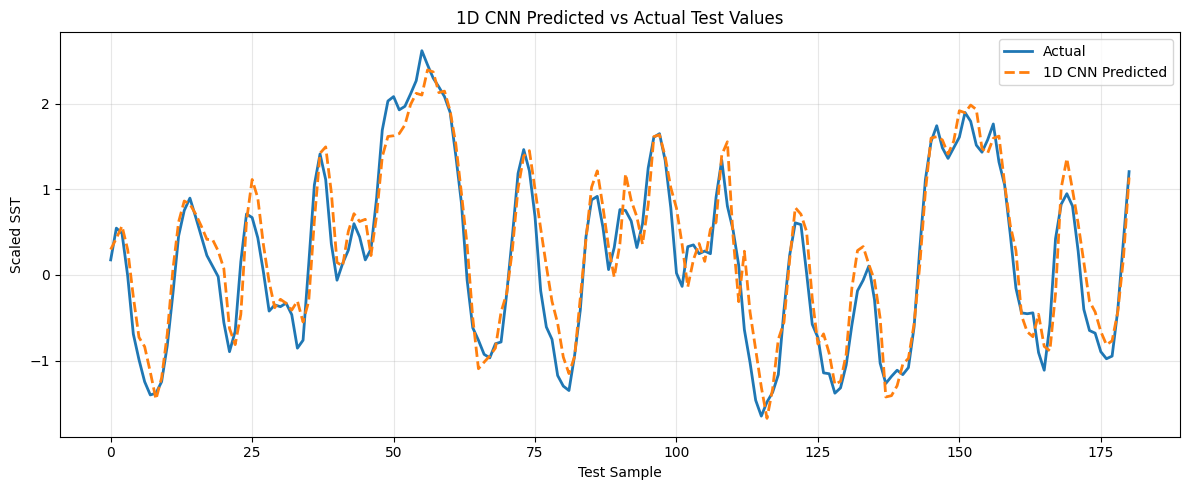

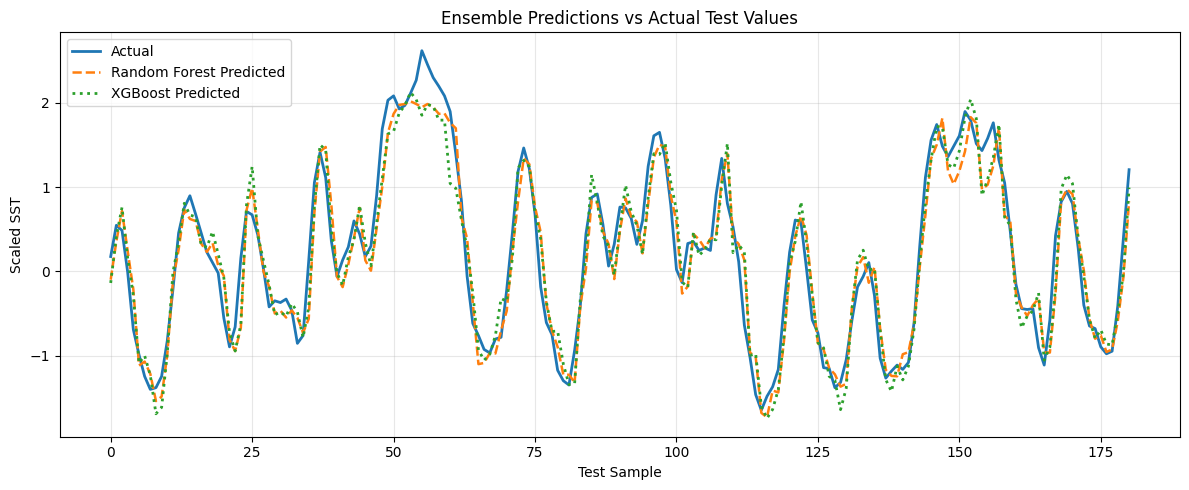

In [30]:
prediction_plot_specs = [
    ("y_pred_OLS", "OLS Predicted", "ols_predictions.png"),
    ("y_pred_CART", "CART Predicted", "cart_predictions.png"),
    ("y_pred_Random_Forest", "Random Forest Predicted", "ensemble_predictions.png"),
    ("y_pred_CNN_1D", "1D CNN Predicted", "cnn_1d_predictions.png"),
]

for pred_col, label, filename in prediction_plot_specs:
    plt.figure(figsize=(12, 5))
    plt.plot(y_test, label="Actual", linewidth=2)
    plt.plot(all_predictions_df[pred_col], label=label, linestyle="--", linewidth=2)
    plt.xlabel("Test Sample")
    plt.ylabel("Scaled SST")
    plt.title(f"{label} vs Actual Test Values")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(data_dir / filename, dpi=150, bbox_inches="tight")
    plt.show()

plt.figure(figsize=(12, 5))
plt.plot(y_test, label="Actual", linewidth=2)
plt.plot(all_predictions_df["y_pred_Random_Forest"], label="Random Forest Predicted", linestyle="--", linewidth=1.8)
plt.plot(all_predictions_df["y_pred_XGBoost"], label="XGBoost Predicted", linestyle=":", linewidth=2)
plt.xlabel("Test Sample")
plt.ylabel("Scaled SST")
plt.title("Ensemble Predictions vs Actual Test Values")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(data_dir / "ensemble_predictions.png", dpi=150, bbox_inches="tight")
plt.show()

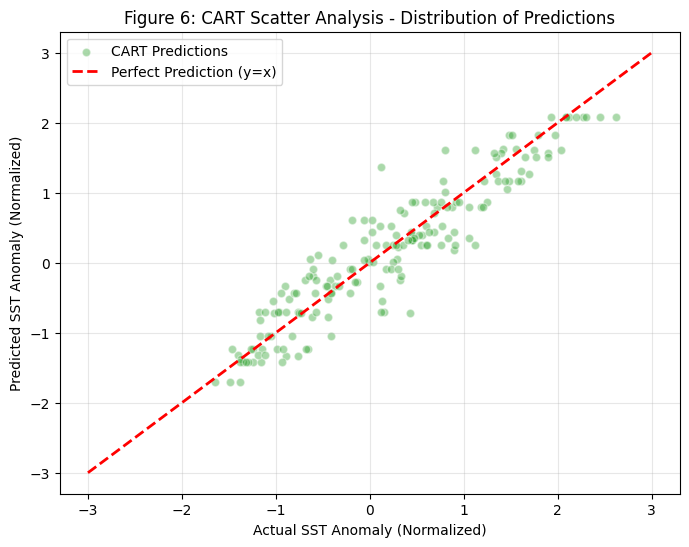

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, all_predictions_df["y_pred_CART"], 
            alpha=0.4, 
            color='#2ca02c', 
            edgecolors='w',
            label='CART Predictions')

plt.plot([-3, 3], [-3, 3], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')

plt.title('Figure 6: CART Scatter Analysis - Distribution of Predictions')
plt.xlabel('Actual SST Anomaly (Normalized)')
plt.ylabel('Predicted SST Anomaly (Normalized)')
plt.legend()
plt.grid(True, alpha=0.3)

save_path = data_dir / "cart_scatter_analysis.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")

plt.show()

## 10. Final Model Comparison

Final model comparison sorted by test R^2:


,Model,RMSE_Train,MAE_Train,R2_Train,RMSE_Test,MAE_Test,R2_Test,RMSE_Val,MAE_Val,R2_Val
0,OLS Linear Regression,0.272385,0.214191,0.926372,0.236702,0.181033,0.946104,NaN,NaN,NaN
1,Random Forest Regressor,0.118005,0.093377,0.986181,0.292168,0.233270,0.917886,NaN,NaN,NaN
2,XGBoost Regressor,0.052902,0.040193,0.997223,0.301099,0.243279,0.912789,NaN,NaN,NaN
3,1D CNN,0.289163,0.226482,0.918749,0.306266,0.244361,0.909770,0.307928,0.242952,0.897003
4,CART Decision Tree,0.221752,0.172665,0.951201,0.361316,0.281625,0.874417,NaN,NaN,NaN


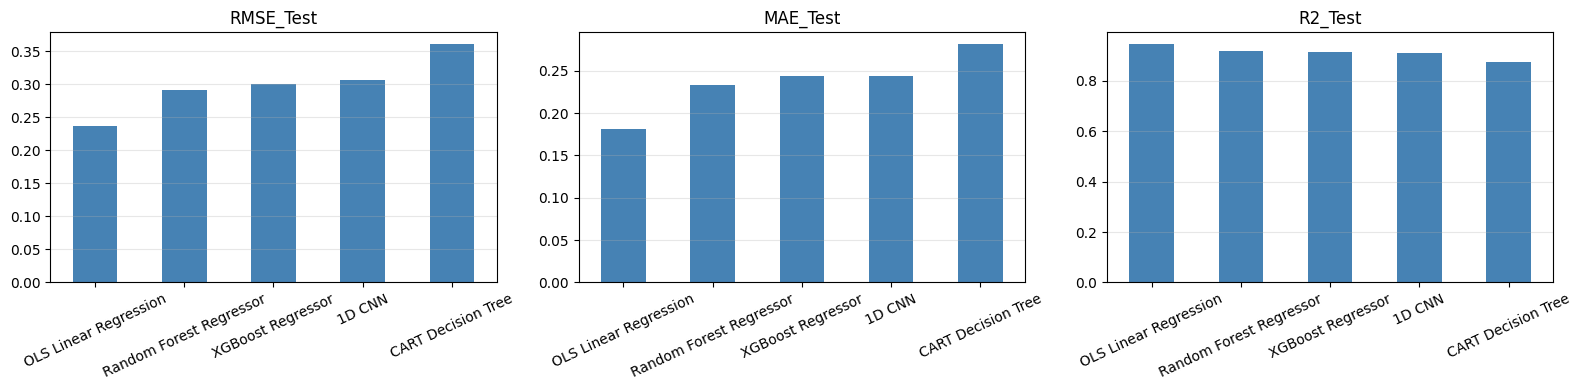

In [31]:
comparison_df = pd.DataFrame(metrics_rows)
comparison_df = comparison_df.sort_values("R2_Test", ascending=False).reset_index(drop=True)
comparison_df.to_csv(data_dir / "model_comparison_metrics.csv", index=False)
all_predictions_df.to_csv(data_dir / "all_model_test_predictions.csv", index=False)

print("Final model comparison sorted by test R^2:")
display(comparison_df)

metrics_plot = comparison_df.set_index("Model")[["RMSE_Test", "MAE_Test", "R2_Test"]]
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, metric in zip(axes, metrics_plot.columns):
    metrics_plot[metric].plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(data_dir / "all_model_metrics_comparison.png", dpi=150, bbox_inches="tight")
plt.show()